# Laborator 7 — Machine Learning cu scikit-learn
## Proiect — Pipeline general de clasificare

**PROIECT LABORATOR 7**

**Pipeline general de clasificare — De la date brute la un sistem ML optimizat**

Acest proiect te ghidează pas cu pas în construirea unui flux complet de machine learning pentru o **problemă generală de clasificare supervizată**.  

Trebuie să alegi:

- un **set de date de pe Kaggle** cu o coloană țintă clară pentru clasificare
- un **clasificator** (ex.: KNN, Decision Tree, Random Forest, Regresie Logistică, SVM etc.)

Documentează-ți alegerile în mod clar:
- numele setului de date și linkul
- coloana țintă și caracteristicile selectate
- clasificatorul(ele) ales(e)
- justificarea deciziilor de preprocesare și evaluare

---

**PUNCTAJ**

**Secțiuni obligatorii — maxim 7 puncte**

| Nr. | Secțiune | Ce trebuie să conțină | Puncte |
|:---:|---|---|:---:|
| 1 | Încărcare și explorare | Încărcare date, definire X/y, statistici descriptive, 2-3 grafice exploratorii | 1.5 |
| 2 | Procesarea caracteristicilor + valori lipsă | Minim o transformare justificată + injectare NaN-uri | 1.0 |
| 3 | Train/test split | Split stratificat | 0.5 |
| 4 | Pipeline de preprocesare | ColumnTransformer cu transformator numeric și categorial + explicații fit vs transform | 1.5 |
| 5 | Modele de referință | Minim 3 modele antrenate și comparate (acuratețe + matrice de confuzie + interpretare) | 1.5 |
| 8 | Curba de antrenare | Grafic train vs validation accuracy + interpretare | 0.5 |
| 9 | Evaluare finală | classification_report + 3 heatmap-uri ale matricei de confuzie (global, pe rânduri, pe coloane) | 0.5 |
| | **Total obligatoriu** | | **7.0** |

**Secțiuni opționale — maxim 3 puncte** *(necesare pentru nota 8, 9 sau 10)*

| Nr. | Secțiune | Ce trebuie să conțină | Puncte |
|:---:|---|---|:---:|
| 6 | Dezechilibru de clase + SMOTE | Analiză distribuție clase + folosirea SMOTE + explicație de ce după preprocesare | 1.0 |
| 7 | Optimizarea hiperparametrilor | GridSearchCV cu minim 2 hiperparametri + raportare best_params și best_score | 1.0 |
| 10 | Importanța caracteristicilor | Extragerea numelor caracteristicilor din pipeline + grafic importanțe/coeficienți + interpretare | 1.0 |
| | **Total opțional** | | **3.0** |


**Notă:** Secțiunile opționale se punctează integral **doar dacă toate secțiunile obligatorii sunt complete**. Punctele parțiale se acordă dacă secțiunea este parțial implementată.


## Spațiu de lucru
Mai jos se află celulele de cod pe care trebuie să le completezi.  
Ele urmează secțiunile exacte ale proiectului, dar implementarea trebuie adaptată la **setul de date Kaggle ales de tine**.

### 0. Configurare

In [1]:
# TODO: Rulează această celulă prima (importuri + setări)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Alege un model de clasificare (decomentează unul dintre următoarele)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Avansat: SMOTE (instalează dacă este necesar în Colab)
# !pip -q install imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

### SECȚIUNEA 1 — Încărcarea și explorarea setului de date

In [2]:
# TODO 1.1–1.2:
# - Încarcă setul de date Kaggle ales
# - Definește X (caracteristici) și y (țintă)
# - Afișează primele 10 rânduri din X
# - Dacă este necesar, codifică etichetele țintă

# EXEMPLU:
df = pd.read_csv("/content/cybersecurity_threat_dataset.csv")

# TODO:
df.head()

# TODO:
coloana_tinta = "label"
X = df.drop(columns=[coloana_tinta])
y = df[coloana_tinta]

# Opțional:
if y.dtype == "object":
    le = LabelEncoder()
    y = le.fit_transform(y)

# TODO:
X.head(10)

,timestamp,ioc_value,ioc_type,threat_type,malware_family,confidence_level,src_country,dst_port,tags,reporter,days_active
0,2026-05-30 07:53:39.227712+00:00,fallback_malicious_16c3ef0b.com,domain,botnet_cc,unknown_fallback,50,XX,80,fallback,fallback_gen,1
1,2026-05-30 07:53:39.227749+00:00,fallback_malicious_183a3d4c.com,domain,botnet_cc,unknown_fallback,50,XX,80,fallback,fallback_gen,1
2,2026-05-30 07:53:39.227686+00:00,fallback_malicious_62271f88.com,domain,botnet_cc,unknown_fallback,50,XX,80,fallback,fallback_gen,1
3,2026-05-30 07:53:39.227763+00:00,fallback_malicious_2974b129.com,domain,botnet_cc,unknown_fallback,50,XX,80,fallback,fallback_gen,1
4,2026-05-30 07:53:39.227686+00:00,fallback_malicious_62271f88.com,domain,botnet_cc,unknown_fallback,50,XX,80,fallback,fallback_gen,1
5,2026-05-30 07:53:39.227701+00:00,fallback_malicious_2003d49c.com,domain,botnet_cc,unknown_fallback,50,XX,80,fallback,fallback_gen,1
6,2026-05-30 07:53:39.227737+00:00,fallback_malicious_4533c6ad.com,domain,botnet_cc,unknown_fallback,50,XX,80,fallback,fallback_gen,1
7,2026-05-30 07:53:39.227686+00:00,fallback_malicious_62271f88.com,domain,botnet_cc,unknown_fallback,50,XX,80,fallback,fallback_gen,1
8,2026-05-30 07:53:39.227775+00:00,fallback_malicious_8c7d9090.com,domain,botnet_cc,unknown_fallback,50,XX,80,fallback,fallback_gen,1
9,2026-05-30 07:53:39.227701+00:00,fallback_malicious_2003d49c.com,domain,botnet_cc,unknown_fallback,50,XX,80,fallback,fallback_gen,1


In [3]:
# TODO 1.3:
# Calculează statistici descriptive de bază:
# - medie, mediană, std pentru coloanele numerice
# - clasele unice ale lui y
# - opțional: distribuția claselor

# INDICIU:
X.describe(include="all")
X.median(numeric_only=True)
X.std(numeric_only=True)
pd.Series(y).unique()
pd.Series(y).value_counts()

,count
label,
1,4500
0,500


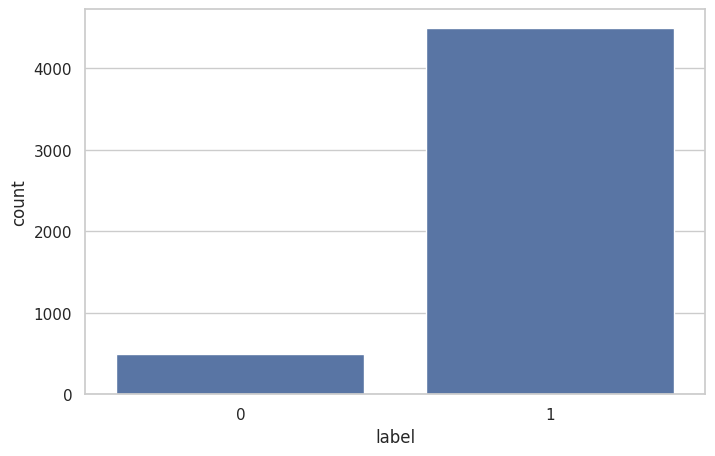

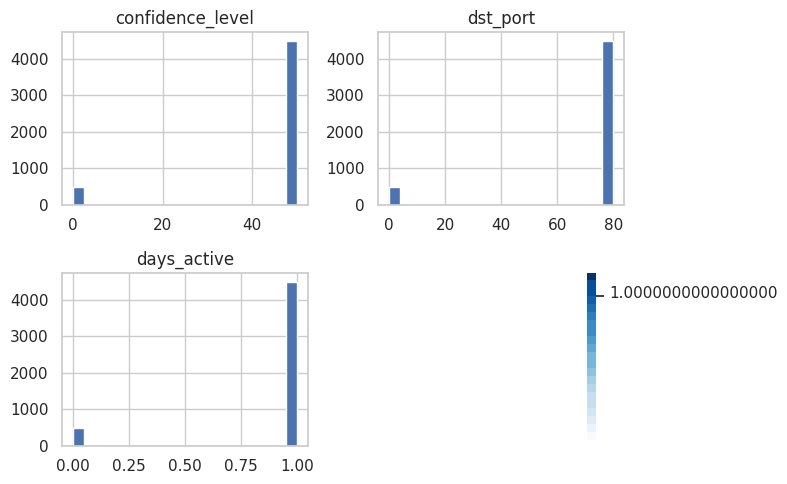

In [4]:
# TODO 1.4:
# Creează 2–3 vizualizări exploratorii adecvate setului tău de date.
# Exemple:
# - countplot al claselor țintă
# - histograme ale caracteristicilor numerice
# - boxplot-uri grupate după clasă
# - pairplot (doar dacă setul de date este suficient de mic)
# - heatmap a corelației pentru caracteristicile numerice

# INDICIU:
sns.countplot(x=pd.Series(y))
X.select_dtypes(include=np.number).hist(bins=20)
sns.heatmap(X.select_dtypes(include=np.number).corr(), annot=False, cmap="Blues")
plt.tight_layout(); plt.show()

### SECȚIUNEA 2 — Procesarea caracteristicilor și adăugarea valorilor lipsă

In [5]:
# TODO 2.1:
# Realizează un pas mic de procesare a caracteristicilor adecvat setului tău de date.
# Exemple:
# - creează o caracteristică categorială dintr-una numerică folosind pd.cut()
# - combină două caracteristici existente
# - extrage o componentă utilă dintr-o coloană de tip string/dată
# - elimină o coloană identificator irelevantă
#
# Scrie 1–3 propoziții (Markdown) explicând de ce această transformare poate ajuta.

# EXEMPLU:
X["confidence_cat"] = pd.cut(
    X["confidence_level"],
    bins=[0, 33, 66, 100],
    labels=["low", "medium", "high"]
)

# Coloana `confidence_level` conține valori numerice între 0 și 100, reprezentând nivelul de încredere al raportorului.
# Prin discretizare în 3 categorii (low/medium/high), modelul poate învăța mai ușor pattern-uri asociate nivelului de risc.
# Această transformare reduce zgomotul din date și poate îmbunătăți performanța clasificatorului.

In [6]:
# TODO 2.2:
# Injectează aleatoriu o cantitate mică de valori lipsă (~5%) în unele coloane numerice
# folosind o mască. Apoi scrie 1–3 propoziții (Markdown) explicând de ce imputăm DUPĂ
# împărțirea setului de date.

rng = np.random.RandomState(RANDOM_STATE)

# TODO:
coloane_numerice = X.select_dtypes(include=np.number).columns.tolist()

# EXEMPLU OPȚIONAL:
masca = rng.rand(*X[coloane_numerice].shape) < 0.05
X_num = X[coloane_numerice].copy()
X_num = X_num.mask(masca)
X[coloane_numerice] = X_num

# TODO: verifică
X.isna().sum()

,0
timestamp,0
ioc_value,0
ioc_type,0
threat_type,0
malware_family,0
confidence_level,222
src_country,0
dst_port,257
tags,500
reporter,0


### SECȚIUNEA 3 — Împărțirea în seturi de antrenare și test

In [25]:
# TODO 3.1:
# Împarte X și y în antrenare și test:
# - test_size=0.2
# - random_state=42
# - stratify=y
# Apoi scrie 1–3 propoziții (Markdown) despre de ce stratificarea este importantă.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Stratificarea asigură că proporția claselor (0 și 1) este păstrată atât în setul de antrenament cât și în cel de test.
# Fără stratificare, din cauza dezechilibrului dintre clase, setul de test ar putea conține prea puține exemple dintr-o clasă, afectând evaluarea modelului.
# Astfel, metricile calculate pe setul de test reflectă corect performanța reală a modelului.

### SECȚIUNEA 4 — Pipeline de preprocesare (ColumnTransformer)

In [8]:
# TODO 4.1:
# Definește listele de caracteristici numerice și categoriale automat sau manual.

# EXEMPLU:
caracteristici_numerice = X_train.select_dtypes(include=np.number).columns.tolist()
caracteristici_categoriale = X_train.select_dtypes(exclude=np.number).columns.tolist()

# TODO:
print("Numerice:", caracteristici_numerice)
print("Categoriale:", caracteristici_categoriale)

Numerice: ['confidence_level', 'dst_port', 'days_active']
Categoriale: ['timestamp', 'ioc_value', 'ioc_type', 'threat_type', 'malware_family', 'src_country', 'tags', 'reporter', 'confidence_cat']


In [9]:
# TODO 4.2–4.4:
# Construiește preprocesarea:
# - pipeline numeric: SimpleImputer(medie sau mediană) + StandardScaler
# - pipeline categorial: SimpleImputer(most_frequent) + OneHotEncoder(handle_unknown="ignore")
# - combină cu ColumnTransformer într-un preprocessor

transformator_numeric = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

transformator_categorial = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", transformator_numeric, caracteristici_numerice),
    ("cat", transformator_categorial, caracteristici_categoriale)
])

**TODO 4.5 (scrie într-o celulă Markdown):**
- fit vs transform
- De ce preprocesarea trebuie să facă parte din fluxul ML
- De ce scalarea se aplică în principal variabilelor numerice
- De ce variabilele categoriale necesită adesea codificare

## Preprocesarea datelor

**fit vs transform:** `fit()` învață parametrii din datele de antrenament, `transform()` îi aplică. Se folosește `fit_transform()` doar pe train pentru a evita *data leakage*.

**Preprocesarea în pipeline:** Integrată în `Pipeline`, transformările se aplică separat pe train și test, prevenind scurgerea informațiilor din setul de test.

**Scalarea variabilelor numerice:** Aduce toate valorile la aceeași scară, evitând ca variabilele cu valori mari să domine modelul.

**Codificarea variabilelor categoriale:** Modelele ML lucrează doar cu numere, deci textul (ex: `"botnet"`) trebuie transformat în valori numerice.

### SECȚIUNEA 5 — Modele de referință (Baseline)

In [10]:
# TODO 5.1–5.2:
# Antrenează cel puțin 3 modele de referință folosind un Pipeline:
#   preprocesare -> clasificator
#
# Poți compara:
# - KNN cu valori diferite ale lui k
# - sau mai mulți clasificatori din lab 7 (ex. LogisticRegression, DecisionTree,
#   RandomForest, SVM)
#
# Evaluează fiecare model:
# - acuratețe
# - matrice de confuzie
# - interpretare scurtă (Markdown)

# EXEMPLU:
modele = {
    "KNN-3": KNeighborsClassifier(n_neighbors=3),
    "KNN-5": KNeighborsClassifier(n_neighbors=5),
    "RF": RandomForestClassifier(random_state=RANDOM_STATE)
}

for name, model in modele.items():
    clf = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(name, accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

KNN-3 1.0
[[100   0]
 [  0 900]]
KNN-5 1.0
[[100   0]
 [  0 900]]
RF 1.0
[[100   0]
 [  0 900]]


### SECȚIUNEA 6 — Gestionarea opțională a dezechilibrului de clase cu SMOTE

In [11]:
# TODO 6.1:
# Dacă setul tău de date este dezechilibrat, explorează distribuția claselor și opțional
# creează sau păstrează o versiune dezechilibrată pentru experimente.
#
# Exemple:
# - inspectează numărul de elemente per clasă
# - păstrează dezechilibrul original
# - sau reduce artificial una dintre clase pentru demonstrație
#
# INDICIU:
pd.Series(y).value_counts()

# OPȚIONAL:
df_imb = ...
X_imb = ...
y_imb = ...

In [12]:
# TODO 6.2–6.4:
# Dacă dezechilibrul de clase este relevant pentru setul tău de date:
# - construiește X_imb / y_imb (sau reutilizează X / y)
# - împarte cu stratify
# - construiește ImbPipeline: preprocesare -> SMOTE(...) -> clasificator
# - explică (Markdown) de ce SMOTE trebuie aplicat DUPĂ preprocesare
#
# Dacă setul tău de date nu este dezechilibrat semnificativ, scrie o scurtă notă
# și sari peste SMOTE.

# EXEMPLU:
X_imb = X
y_imb = y

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=RANDOM_STATE, stratify=y_imb
)

pipe = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE))
])

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=RANDOM_STATE, stratify=y_imb
)

pipe = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE))
])

### SECȚIUNEA 7 — Reglarea hiperparametrilor cu GridSearchCV

In [13]:
# TODO 7.1–7.3:
# - Creează o grilă de parametri pentru clasificatorul ales
# - Rulează GridSearchCV cu cv=5, scoring='accuracy'
# - Afișează cei mai buni parametri și cea mai bună acuratețe CV
#
# Adaptează numele parametrilor la clasificatorul din pipeline.

# EXEMPLU pentru RandomForest:
param_grid = {
  "clf__n_estimators": [50, 100],
  "clf__max_depth": [None, 5, 10],
  "clf__min_samples_split": [2, 5]
}

grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_imb, y_train_imb)
print(grid.best_params_, grid.best_score_)

{'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 50} 1.0


### SECȚIUNEA 8 — Vizualizarea curbei de antrenare (learning_curve)

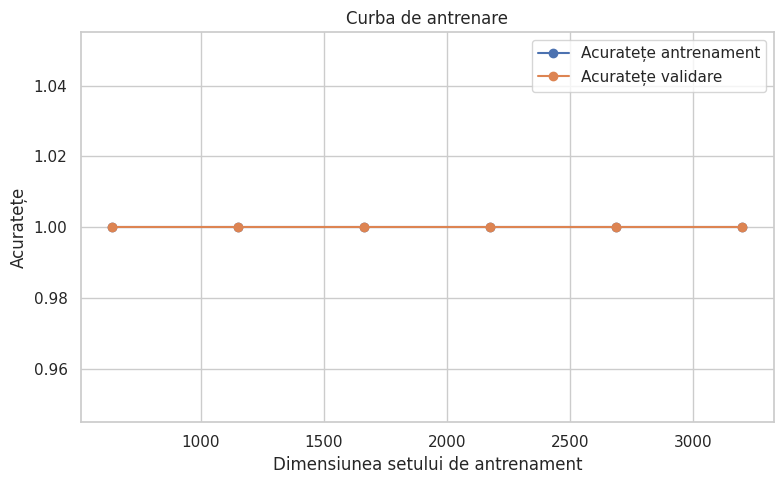

In [23]:
# TODO 8.1:
# Folosește learning_curve() pe cel mai bun estimator (ex. grid.best_estimator_).
# Afișează acuratețea de antrenare și de validare față de dimensiunea setului de antrenare.
# Explică (Markdown): overfitting, underfitting, convergență.

# INDICIU:
cel_mai_bun_model = grid.best_estimator_
train_sizes, train_scores, valid_scores = learning_curve(
    cel_mai_bun_model,
    X_train_imb if "X_train_imb" in globals() else X_train,
    y_train_imb if "y_train_imb" in globals() else y_train,
    cv=5,
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1
)


# Grafic learning curve
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label="Acuratețe antrenament", marker="o")
plt.plot(train_sizes, valid_mean, label="Acuratețe validare", marker="o")
plt.xlabel("Dimensiunea setului de antrenament")
plt.ylabel("Acuratețe")
plt.title("Curba de antrenare")
plt.legend()
plt.tight_layout()
plt.show()

### SECȚIUNEA 9 — Metrici de evaluare și vizualizare

In [15]:
# TODO 9.1–9.2:
# Fă predicții pe setul de test și calculează:
# - acuratețe
# - classification_report
# Explică precizie / recall / f1-score / support (Markdown)

# INDICIU:
eval_X = X_test_imb if "X_test_imb" in globals() else X_test
eval_y = y_test_imb if "y_test_imb" in globals() else y_test
y_pred = cel_mai_bun_model.predict(eval_X)
print("acc:", accuracy_score(eval_y, y_pred))
print(classification_report(eval_y, y_pred))

acc: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       900

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



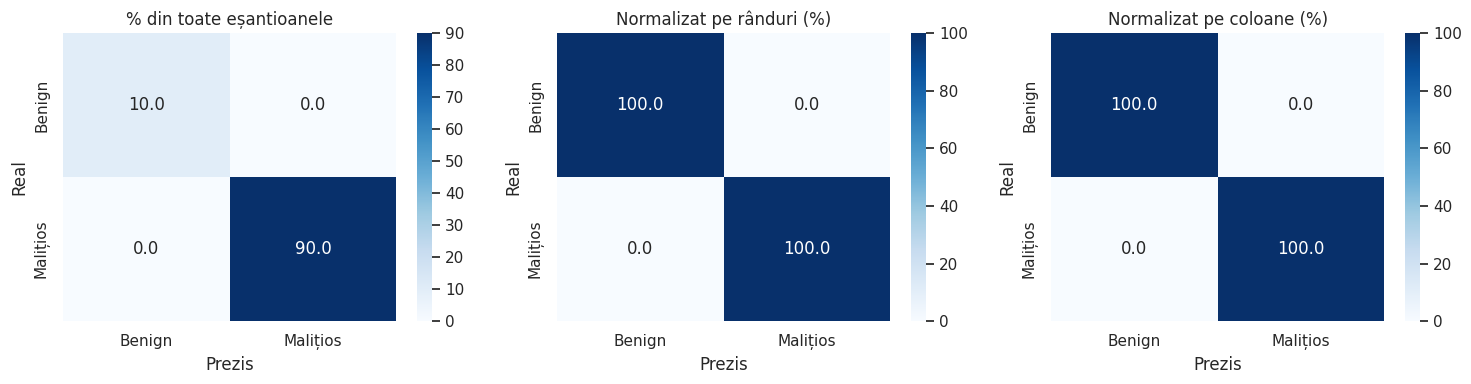

In [18]:
# TODO 9.3:
# Vizualizează matricea de confuzie în procente:
# - % din toate eșantioanele
# - normalizat pe rânduri (%)
# - normalizat pe coloane (%)
# Folosește subplots (3 heatmap-uri).

# INDICIU:
cm = confusion_matrix(eval_y, y_pred)
cm_all = cm / cm.sum() * 100
cm_row = cm / cm.sum(axis=1, keepdims=True) * 100
cm_col = cm / cm.sum(axis=0, keepdims=True) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titles = ["% din toate eșantioanele", "Normalizat pe rânduri (%)", "Normalizat pe coloane (%)"]
matrices = [cm_all, cm_row, cm_col]

for ax, matrix, title in zip(axes, matrices, titles):
    sns.heatmap(matrix, annot=True, fmt=".1f", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Malițios"],
                yticklabels=["Benign", "Malițios"])
    ax.set_title(title)
    ax.set_xlabel("Prezis")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

### SECȚIUNEA 10 — Importanța caracteristicilor

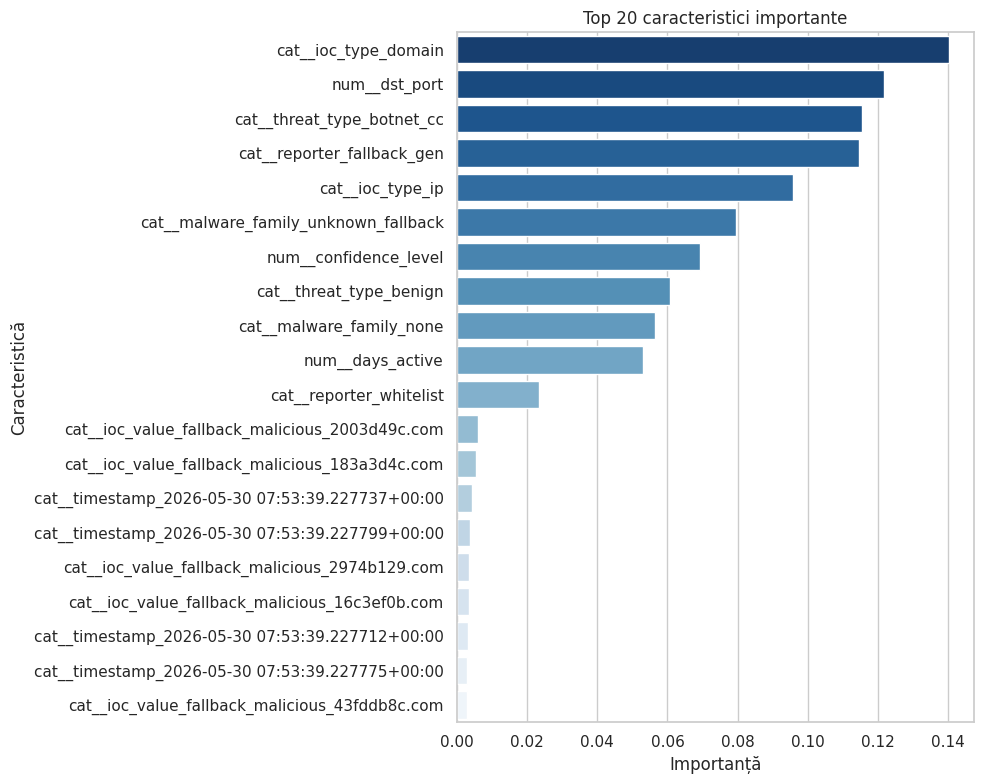

In [24]:
# TODO 10.1–10.2:
# - Extrage numele caracteristicilor după ColumnTransformer folosind get_feature_names_out()
# - Dacă modelul final suportă, afișează importanțele sau coeficienții caracteristicilor
# - Explică (Markdown): care caracteristici contează cel mai mult și cum preprocesarea
#   modifică spațiul caracteristicilor
#
# NOTĂ:
# - modelele bazate pe arbori oferă adesea feature_importances_
# - modelele liniare pot oferi coef_
# - unele modele (ex. KNN) nu oferă importanța directă a caracteristicilor

# INDICIU:
pre = cel_mai_bun_model.named_steps["preprocess"]
toate_caracteristicile = pre.get_feature_names_out()

if hasattr(cel_mai_bun_model.named_steps["clf"], "feature_importances_"):
    importante = cel_mai_bun_model.named_steps["clf"].feature_importances_
elif hasattr(cel_mai_bun_model.named_steps["clf"], "coef_"):
    importante = np.abs(cel_mai_bun_model.named_steps["clf"].coef_).mean(axis=0)


# Grafic importanța caracteristicilor
importanta_df = pd.DataFrame({
    "caracteristica": toate_caracteristicile,
    "importanta": importante
}).sort_values("importanta", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=importanta_df, x="importanta", y="caracteristica", hue="caracteristica", legend=False, palette="Blues_r")
plt.title("Top 20 caracteristici importante")
plt.xlabel("Importanță")
plt.ylabel("Caracteristică")
plt.tight_layout()
plt.show()